# Quantum Optics - Homework 4 - Wigner function of a mechanical resonator

## Jan Chelmecki

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

$$
H / \hbar = g_0 (\sigma^+ a + \sigma^- a^{\dag})
$$

In [65]:
alpha = -2.0
N = 15
g0 = 1.0

print("t_R = ", 2*np.pi*abs(alpha)/g0)

xmax = 4
xvec = np.linspace(-xmax,xmax,201)
yvec = np.linspace(-xmax,xmax,201)

g = basis(2,0)
e = basis(2,1)

H = g0* ( tensor(destroy(2).dag(), destroy(N)) + tensor(destroy(2), destroy(N).dag()) )

t_R =  12.566370614359172


In [80]:
psi0 = tensor(g, coherent(N,alpha))
rho0 = psi0*psi0.dag()
times = np.linspace(0,13,1301)
result = mesolve(H, rho0, times)

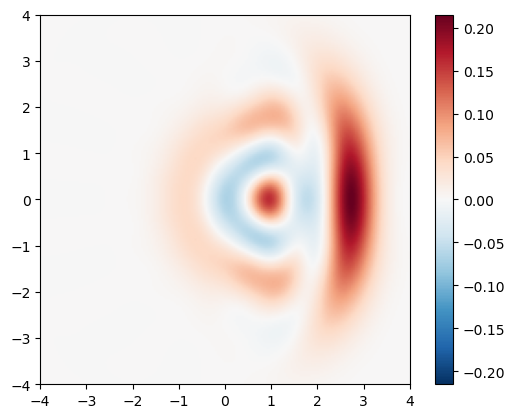

In [85]:
rho = result.states[1257//2*2].ptrace(1)
W = wigner(rho, xvec, yvec)
W_max = np.max(abs(W))
plt.imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax])
plt.colorbar()

## Testing

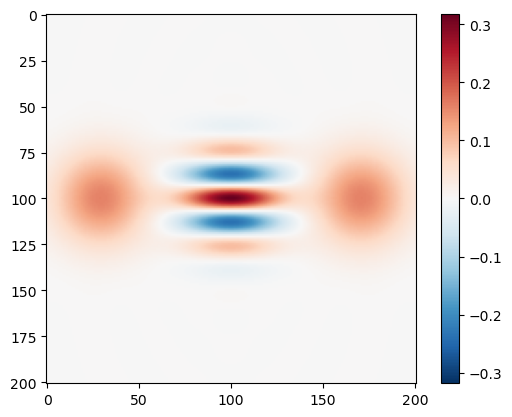

In [62]:
psi = coherent(N,alpha=2.0) + coherent(N,alpha=-2.0)
psi = psi/psi.norm()
W = wigner(psi, xvec, yvec)
W_max = np.max(abs(W))
plt.imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max)
plt.colorbar()

In [ ]:
plt.colorbar()

<function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | ColorizingArtist | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>